In [17]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt

In [19]:
def create_hex_grid(gdf=None, bounds=None, n_cells=10, overlap=True):
    if bounds != None:
        xmin, ymin, xmax, ymax= bounds
    else:
        xmin, ymin, xmax, ymax= gdf.total_bounds

    unit = (xmax-xmin)/n_cells
    a = np.sin(np.pi / 3)
    cols = np.arange(np.floor(xmin), np.ceil(xmax), 3 * unit)
    rows = np.arange(np.floor(ymin) / a, np.ceil(ymax) / a, unit)

    hexagons = []
    for x in cols:
      for i, y in enumerate(rows):
        if (i % 2 == 0):
          x0 = x
        else:
          x0 = x + 1.5 * unit

        hexagons.append(Polygon([
          (x0, y * a),
          (x0 + unit, y * a),
          (x0 + (1.5 * unit), (y + unit) * a),
          (x0 + unit, (y + (2 * unit)) * a),
          (x0, (y + (2 * unit)) * a),
          (x0 - (0.5 * unit), (y + unit) * a),
        ]))

    grid = gpd.GeoDataFrame({'geometry': hexagons},crs=gdf.crs)
    grid["grid_area"] = grid.area
    grid = grid.reset_index().rename(columns={"index": "grid_id"})
    if overlap == True:
        cols = ['grid_id','geometry','grid_area']
        grid = grid.sjoin(gdf, how='inner').drop_duplicates('geometry')
    return grid

In [15]:
county = gpd.read_file('GIS/COUNTY.geojson')
county = county.to_crs('EPSG:26918')

In [31]:
watersheds = gpd.read_file('GIS/WATERSHEDS_CLIPPED.geojson').to_crs('EPSG:26918')

In [71]:
grid = create_hex_grid(watersheds, n_cells=80)
grid.to_file('GIS/FLOOD_GRID.geojson', driver='GeoJSON')

<Axes: >

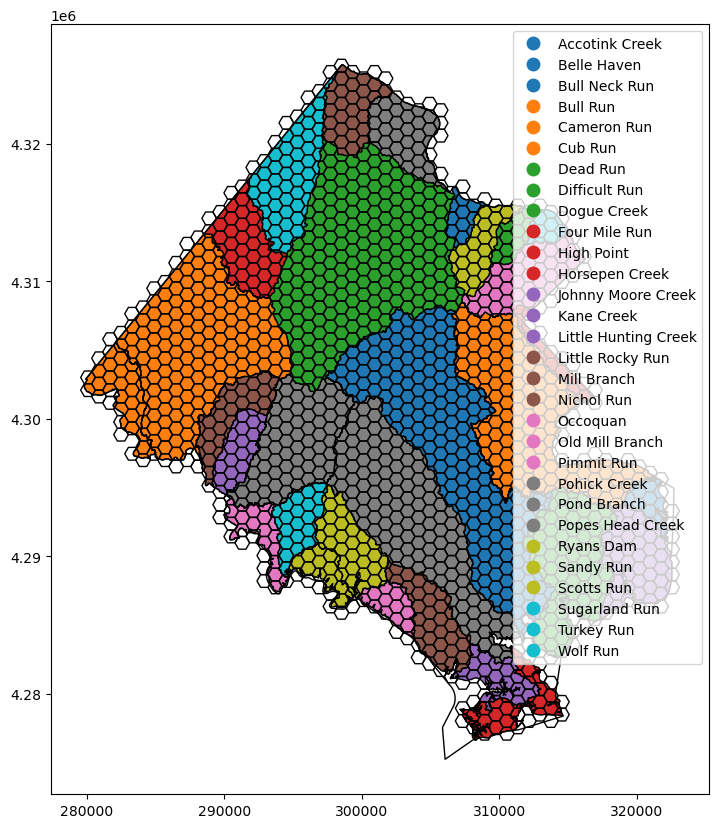

In [73]:
fig, ax = plt.subplots(figsize=(10, 10))
watersheds.plot(ax=ax, edgecolor='black', column='NAME', legend=True)
grid.plot(ax=ax, facecolor='none', edgecolor='black')
county.plot(ax=ax, facecolor='none', edgecolor='black')